# Data5441 - Networks and High-dimensional Inference 
Semester 2, 2026


# Tutorial Week 4

This notebook contains code and guiding questions for your work. You are encouraged to perform calculations, explorations, and estimates here, and to use your results to answer the questions in the following slides. 


In [4]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import networkx as nx
import pandas as pd
from kneed import KneeLocator

RANDOM_SEED = 5441

### Utils: Burnin time calculator

In [5]:
def compute_burn_in(x, y, curve="convex", direction="decreasing"):
    x = x.to_numpy()
    y = y.to_numpy()
    knee = KneeLocator(x, y, curve="convex", direction=direction)
    burnin_time = knee.knee
    return burnin_time

# 1. Introduction

This tutorial focuses on the study of **random graphs**, with a focus on using Markov chain Monte Carlo (MCMC) methods to sample them. Random graphs provide null models against which we can compare a measure $x$ observed in a focus network $g^*\equiv g_s$. As a representative measure, we use the network clustering coefficient $C_{net}$; our focus network is the social network from *Les Misérables*.

Throughout Sections 1.1--1.3, graphs are labelled, undirected, unweighted simple graphs on the fixed node set of $g^*$ unless stated otherwise. The GML data contain edge weights, but the analysis below deliberately ignores them.


## 1.1. General characterization of the focus network


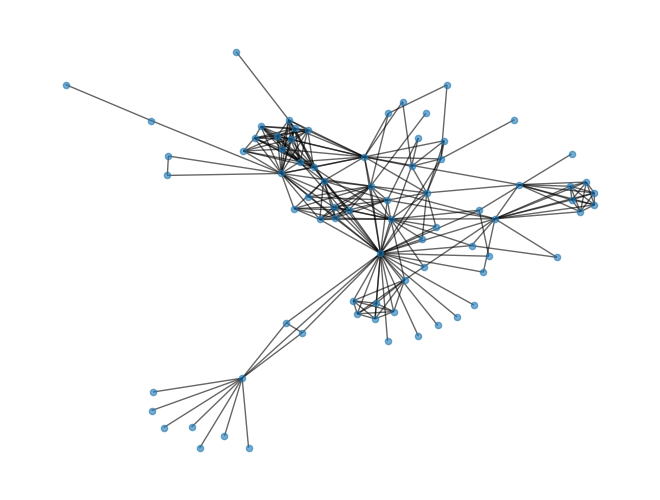

In [6]:
gs = nx.read_gml("./data/lesmiserables.gml")
assert not gs.is_directed()
assert not gs.is_multigraph()
assert nx.number_of_selfloops(gs) == 0

pos = nx.spring_layout(gs, seed=RANDOM_SEED)
nx.draw(gs, pos=pos, node_size=20, alpha=0.6)

In [7]:
print(f"Number of nodes: {gs.number_of_nodes()}\nNumber of edges: {gs.number_of_edges()}") 

Number of nodes: 77
Number of edges: 254


$\sigma_z/\langle z \rangle$ and $C_{net}$


In [8]:
def measuresD(g):
    dictD=dict(g.degree())
    listD=[dictD[k] for k in dictD.keys()]
    return(np.std(listD)/np.average(listD))

In [9]:
print(f"Degree Variability: {measuresD(gs)},\nTransitivity: {nx.transitivity(gs)}")

Degree Variability: 0.9095340315262037,
Transitivity: 0.49893162393162394


## 1.2. Random-Graph models and MCMC

Let $V^*$ be the labelled node set of the focus network. We consider three uniform ensembles of undirected, unweighted simple graphs on $V^*$:

1. $\Omega_1$: all graphs on $V^*$;
2. $\Omega_2$: all graphs on $V^*$ with a fixed number of edges $L=L^*$;
3. $\Omega_3$: all graphs on $V^*$ with the node-specific degree sequence $z_1, z_2, \ldots, z_N$ of $g^*$.

Each graph in an ensemble has probability $p_i(g)=1/|\Omega_i|$. The ensembles are nested: $\Omega_3 \subset \Omega_2 \subset \Omega_1$. Sampling graphs $g$ from them requires different MCMC updates. Each chain starts at $t=0$ from the focus network $g^*$:

1. Dyad resampling: choose a pair of distinct nodes $i,j$ uniformly at random and set $A_{ij}$ to 0 or 1 with equal probability.
2. Edge replacement: choose an edge uniformly at random and remove it, then choose a non-edge uniformly at random and add it.
3. Edge swap: choose two edges uniformly at random and swap their endpoints, rejecting swaps that would create self-loops or parallel edges.

Because the target probability is uniform and these proposals are symmetric, valid proposals have acceptance probability one. Below we implement and study the MCMC method for case 2. Cases 1 and 3 are considered in the exercises below. 


## 1.3. Case 2: Edge replacement

The function below updates a graph in place by removing one edge and adding one non-edge. Because the removed edge becomes a non-edge, the update may re-add it and leave the graph unchanged.


In [10]:
def T2(g, rng):
    """Perform one fixed-$L$ edge-replacement update in place."""
    edge_remove = list(g.edges())[rng.integers(g.number_of_edges())]
    g.remove_edge(*edge_remove)

    # nx.non_edges() contains only pairs of distinct, non-adjacent nodes.
    nonedges = list(nx.non_edges(g))
    edge_add = nonedges[rng.integers(len(nonedges))]
    g.add_edge(*edge_add)
    return g

The code below explores $\Omega_2$ with uniform probability: the space of random graphs with fixed $N$ and $L$. We use it to compare the focus network $g^*$ with this random-graph ensemble. In particular, we will:
- compute how the clustering coefficient $C$ depends on $t$;
- compute how the degree fluctuations $\sigma_z/\langle z \rangle$ depend on $t$.

To make these comparisons, we need to evaluate the equilibration time of the Markov chain.


In [11]:
def run_omega_2_simulation(gs, transf_func, seed, tmax=100, step=10):
    # Preserve the empirical network stored in gs.
    g = gs.copy()

    rng_te = np.random.default_rng(seed)

    # Store tmax observations from t=0 through t=(tmax-1)*step.
    outs = []

    N0 = g.number_of_nodes()
    L0 = g.number_of_edges()

    for i in range(tmax):
        out = [i * step, nx.number_of_edges(g), measuresD(g), nx.transitivity(g)]
        outs.append(out)
        for _ in range(step):
            g = transf_func(g, rng_te)
        assert g.number_of_nodes() == N0
        assert g.number_of_edges() == L0
        assert nx.number_of_selfloops(g) == 0

    output = pd.DataFrame(outs, columns=["time", "edges", "degree_variability", "transitivity"])

    return output

output = run_omega_2_simulation(gs, transf_func=T2, seed=RANDOM_SEED, tmax=100, step=10)
output.head()

,time,edges,degree_variability,transitivity
0,0,254,0.909534,0.498932
1,10,254,0.881547,0.481278
2,20,254,0.855785,0.437146
3,30,254,0.822359,0.407436
4,40,254,0.795807,0.375755


Plotting the results:


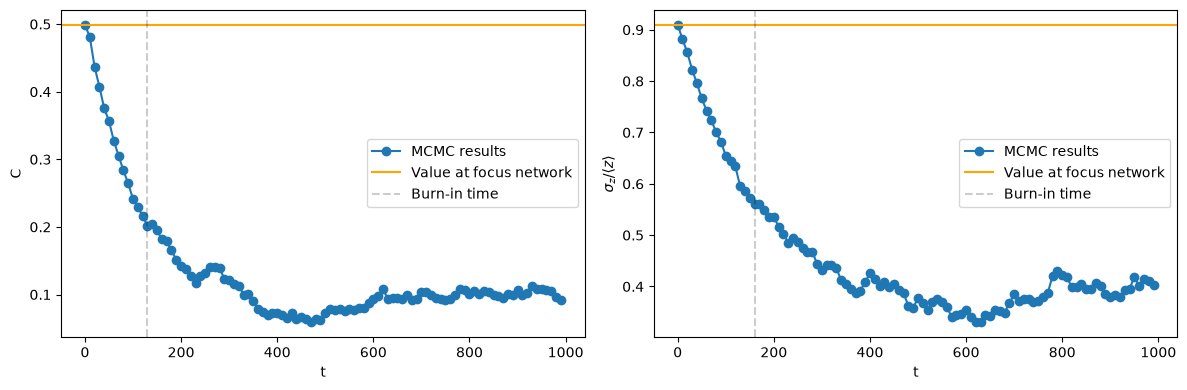

In [12]:
ts = output["time"]
sigmas = output["degree_variability"]
Cs = output["transitivity"]

C_burnin = compute_burn_in(ts, Cs, curve="convex", direction="decreasing")
sigma_burnin = compute_burn_in(ts, sigmas, curve="convex", direction="decreasing")

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Transitivity
axs[0].plot(ts, Cs, "-o", label="MCMC results")
axs[0].axhline(nx.transitivity(gs), label="Value at focus network", color="orange")
axs[0].axvline(C_burnin, linestyle="--", color="black", label="Burn-in time", alpha=0.2)
axs[0].set_ylabel("C")
axs[0].set_xlabel("t")
axs[0].legend()

# Degree variability
axs[1].plot(ts, sigmas, "-o", label="MCMC results")
axs[1].axhline(measuresD(gs), label="Value at focus network", color="orange")
axs[1].axvline(sigma_burnin, linestyle="--", color="black", label="Burn-in time", alpha=0.2)
axs[1].set_ylabel(r"$\sigma_z/\langle z \rangle$")
axs[1].set_xlabel("t")
axs[1].legend()

plt.tight_layout()
plt.show()

In [13]:
C_burnin / gs.number_of_edges()

np.float64(0.5118110236220472)

## Exercise 1.1. Fixed N and L

Change the code above (e.g., varying "lag" and "tmax") and consider the theoretical results discussed in class to answer the following questions:

- Why do we observe a sharp decay over $t$ in the curves above?
- How long does this "transient" last before the chain equilibrates?
- How should the properties of this random graph (e.g., $\bar{C}$) be estimated from the MCMC sample? Are the two properties of $g^*$ discussed above ($C$ and $\sigma_z/\langle z \rangle$) expected under this random-graph model?
- How can we obtain approximately independent samples $g(t)$ from this MCMC?
- For long $t$, will $g^*$ be sampled again?




In [14]:
steps = [10, 20, 50, 70, 100]
tmx = [50, 100, 200, 500, 1000]

RUN = False
OUTPUT_DIR = Path("outputs/omega_2")
OUTPUT_DIR.mkdir(exist_ok=True)

focus_C, focus_sigma = nx.transitivity(gs), measuresD(gs)

if RUN:
    for tmax in tmx:
        for step in steps:
            print(f"Running tmax={tmax}, step={step}...")
            output = run_omega_2_simulation(gs, transf_func=T2, seed=RANDOM_SEED, tmax=tmax, step=step)
            output.to_csv(OUTPUT_DIR / f"simulation_tmax{tmax}_step{step}.csv", index=False)

tmax=50, step=10: C=nan, sigma=nan
tmax=50, step=20: C=nan, sigma=nan
tmax=50, step=50: C=nan, sigma=nan
tmax=50, step=70: C=nan, sigma=nan
tmax=50, step=100: C=nan, sigma=nan
tmax=100, step=10: C=nan, sigma=nan
tmax=100, step=20: C=nan, sigma=nan
tmax=100, step=50: C=nan, sigma=nan
tmax=100, step=70: C=nan, sigma=nan
tmax=100, step=100: C=nan, sigma=nan
tmax=200, step=10: C=nan, sigma=nan
tmax=200, step=20: C=nan, sigma=nan
tmax=200, step=50: C=nan, sigma=nan
tmax=200, step=70: C=nan, sigma=nan
tmax=200, step=100: C=nan, sigma=nan
tmax=500, step=10: C=0.08555558354903713, sigma=0.3715448459784001
tmax=500, step=20: C=0.08404454760638999, sigma=0.36071606588997823
tmax=500, step=50: C=0.08619658540292918, sigma=0.3596167484403032
tmax=500, step=70: C=0.08482786436632794, sigma=0.36321756965762697
tmax=500, step=100: C=0.08632839026351877, sigma=0.36472889246640067
tmax=1000, step=10: C=0.08438803840638685, sigma=0.36360931847895944
tmax=1000, step=20: C=0.08425737289927118, sigma=0.362

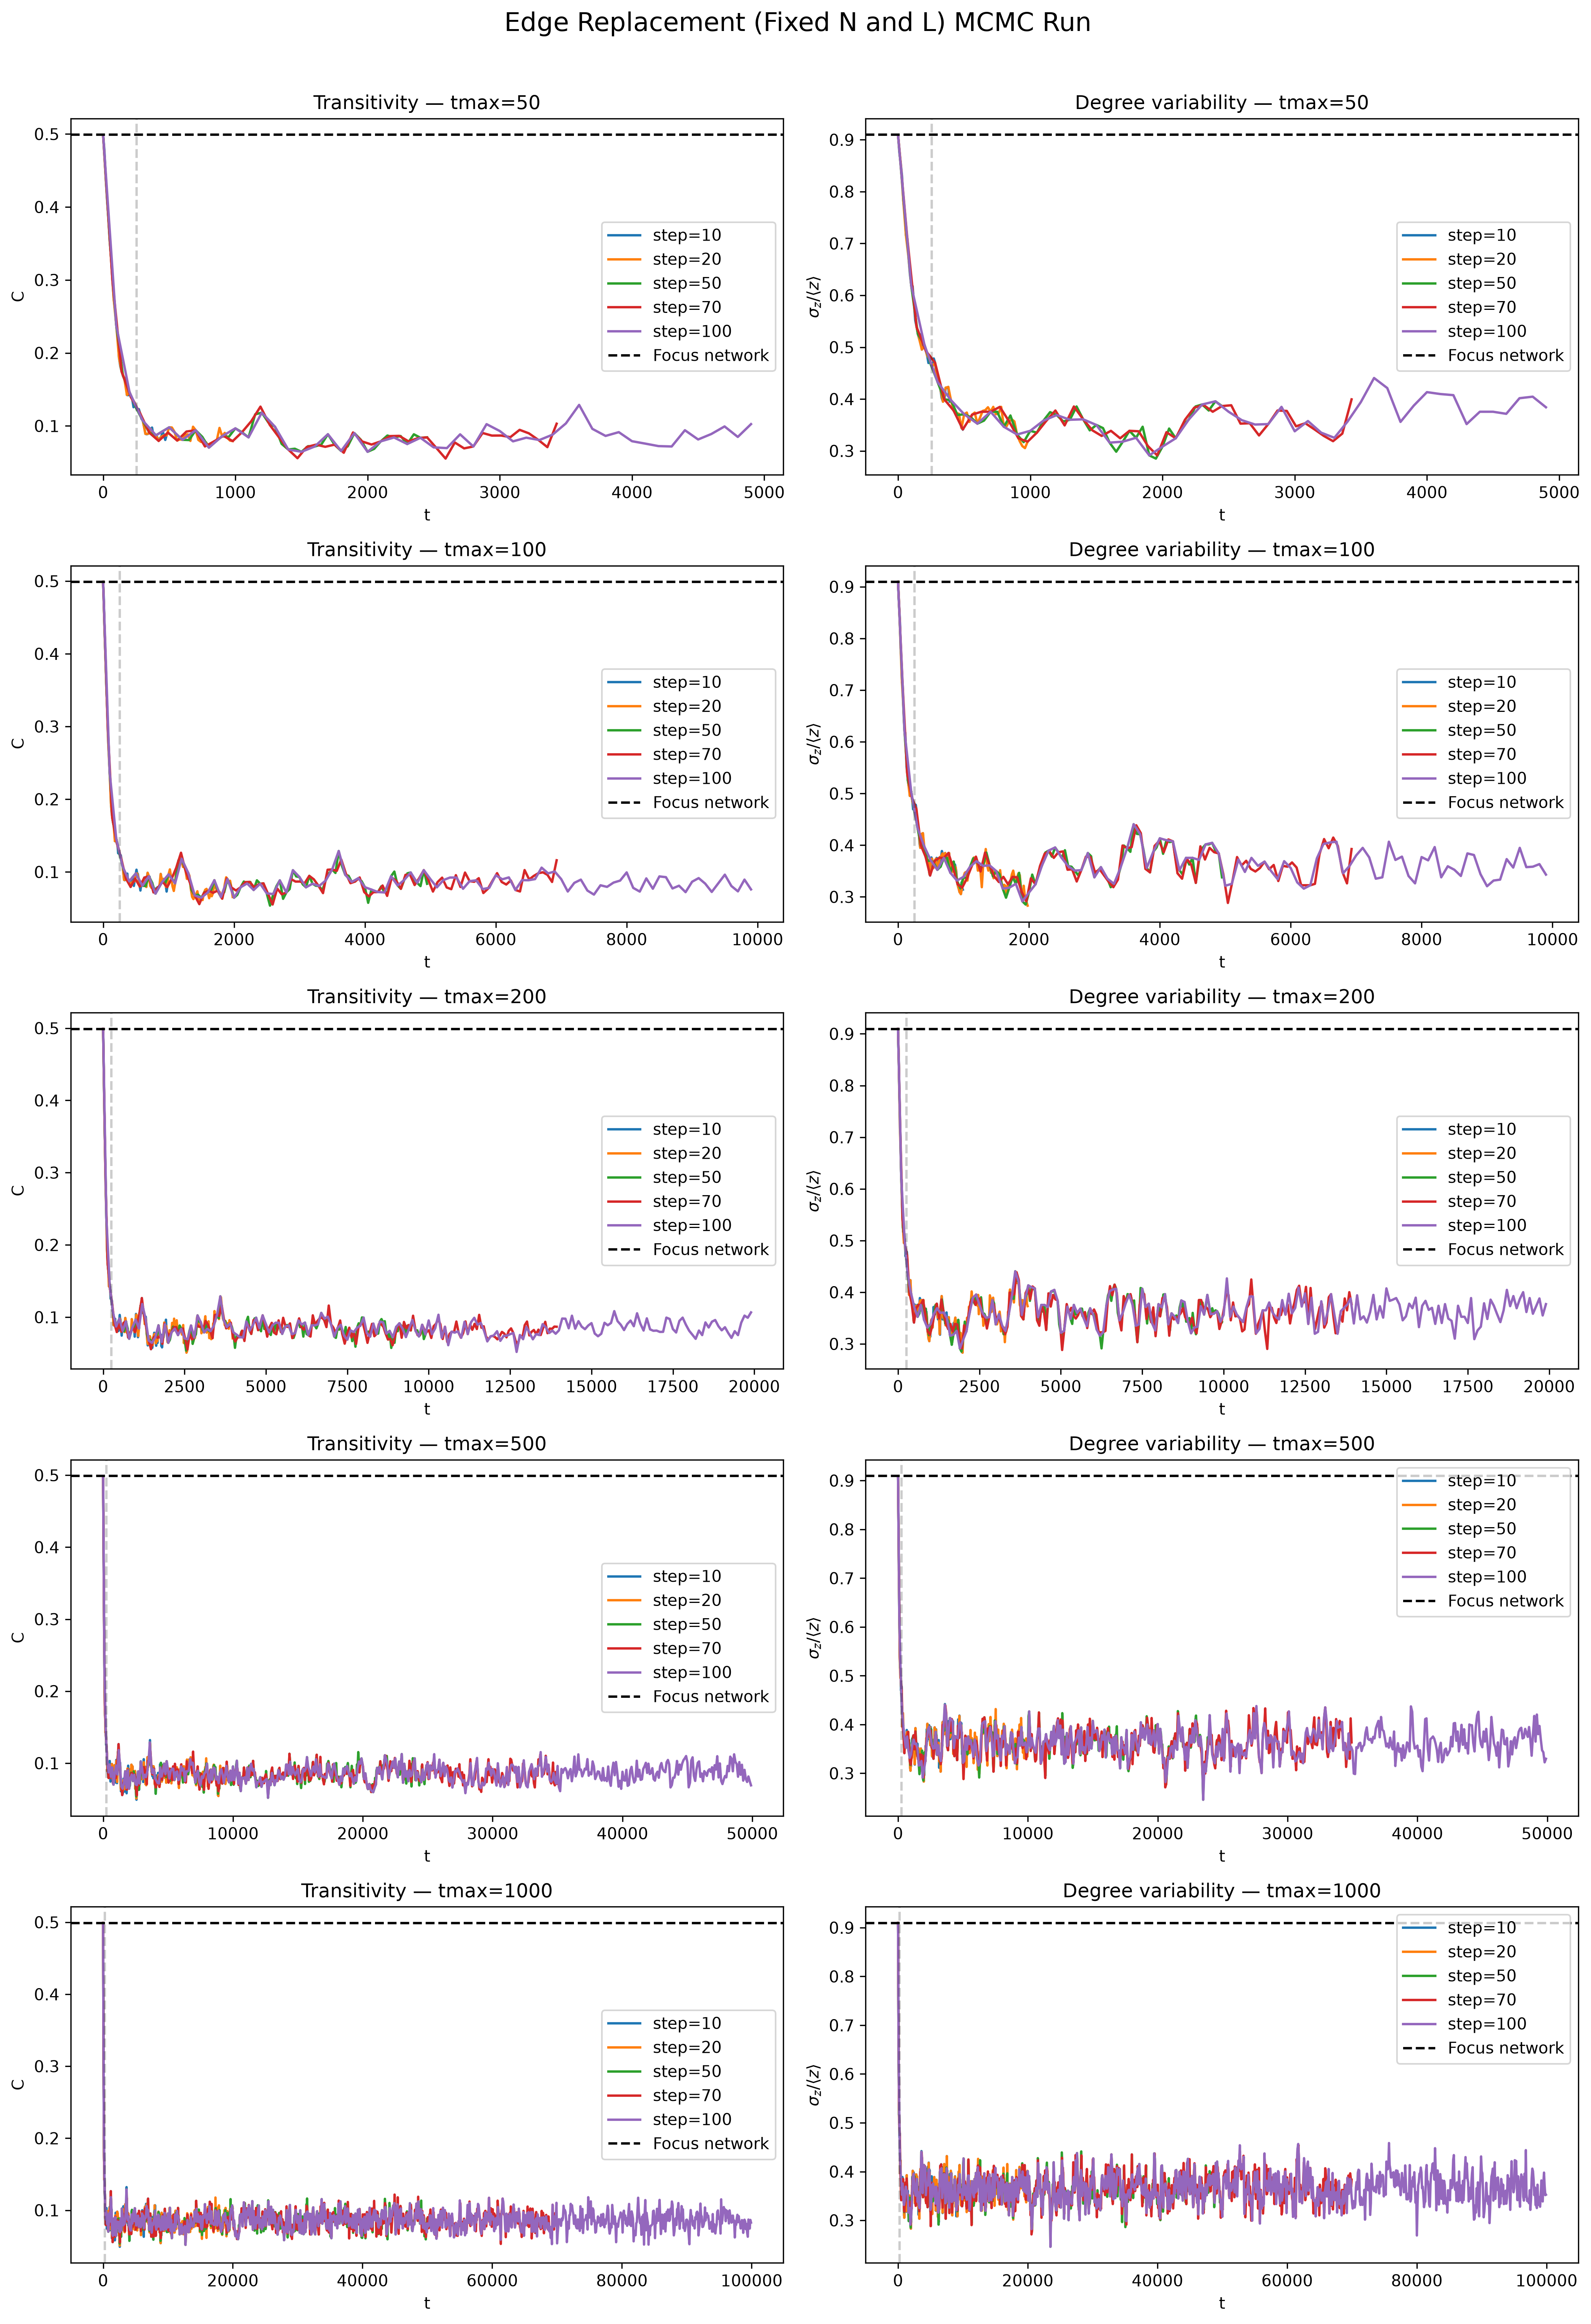

In [15]:
fig, axs = plt.subplots(5, 2, figsize=(14, 20), dpi=300)

for i, tmax in enumerate(tmx):
    for step in steps:
        output = pd.read_csv(OUTPUT_DIR / f"simulation_tmax{tmax}_step{step}.csv")
        ts, Cs, sigmas = output["time"], output["transitivity"], output["degree_variability"]

        average_C = np.mean(Cs[gs.number_of_edges():])
        average_sigma = np.mean(sigmas[gs.number_of_edges():])
        print(f"tmax={tmax}, step={step}: C={average_C}, sigma={average_sigma}")

        
        axs[i, 0].plot(ts, Cs, label=f"step={step}")
        axs[i, 1].plot(ts, sigmas, label=f"step={step}")

    axs[i, 0].axvline(gs.number_of_edges(), linestyle="--", color="black", alpha=0.2)
    axs[i, 1].axvline(gs.number_of_edges(), linestyle="--", color="black", alpha=0.2)

    axs[i, 0].axhline(focus_C, linestyle="--", color="black", label="Focus network")
    axs[i, 1].axhline(focus_sigma, linestyle="--", color="black", label="Focus network")

    axs[i, 0].set(xlabel="t", ylabel="C", title=f"Transitivity — tmax={tmax}")
    axs[i, 1].set(xlabel="t", ylabel=r"$\sigma_z/\langle z \rangle$", title=f"Degree variability — tmax={tmax}")

    axs[i, 0].legend()
    axs[i, 1].legend()

plt.suptitle("Edge Replacement (Fixed N and L) MCMC Run", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Exercise 1.2. Fixed N only

Repeat the analysis above for the first random graph, based on $\Omega_1$:

- Check how different properties $x$ depend on $t$, and whether the equilibration time matches your expectations.
- Plot $C(t)$ and discuss the main characteristics of the curve.


In [16]:
def T1(g, rng):
    nodes = list(g.nodes())
    i, j = rng.choice(nodes, size=2, replace=False)

    if g.has_edge(i, j):
        g.remove_edge(i, j)
    else:
        g.add_edge(i, j)

    return g

def run_omega_1_simulation(gs, transf_func, seed, tmax=100, step=10):
    # Preserve the empirical network stored in gs.
    g = gs.copy()

    rng_te = np.random.default_rng(seed)

    # Store tmax observations from t=0 through t=(tmax-1)*step.
    outs = []

    N0 = g.number_of_nodes()

    for i in range(tmax):
        degrees = [g.degree(n) for n in g.nodes()]
        out = [i * step, nx.number_of_edges(g), measuresD(g), nx.transitivity(g), np.average(degrees)]
        outs.append(out)
        for _ in range(step):
            g = transf_func(g, rng_te)
        assert g.number_of_nodes() == N0
        assert nx.number_of_selfloops(g) == 0

    output = pd.DataFrame(outs, columns=["time", "edges", "degree_variability", "transitivity", "average_degree"])

    return output

In [17]:
steps = [10, 20, 50, 70, 100]
tmx = [50, 100, 200, 500, 1000]

RUN = False
OUTPUT_DIR = Path("outputs/omega_1")
OUTPUT_DIR.mkdir(exist_ok=True)

gs_degrees = [gs.degree(n) for n in gs.nodes()]

focus_degree, focus_C, focus_sigma = np.average(gs_degrees), nx.transitivity(gs), measuresD(gs)

if RUN:
    for tmax in tmx:
        for step in steps:
            # print(f"Running tmax={tmax}, step={step}...")
            output = run_omega_1_simulation(gs, transf_func=T1, seed=RANDOM_SEED, tmax=tmax, step=step)
            output.to_csv(OUTPUT_DIR / f"simulation_tmax{tmax}_step{step}.csv", index=False)

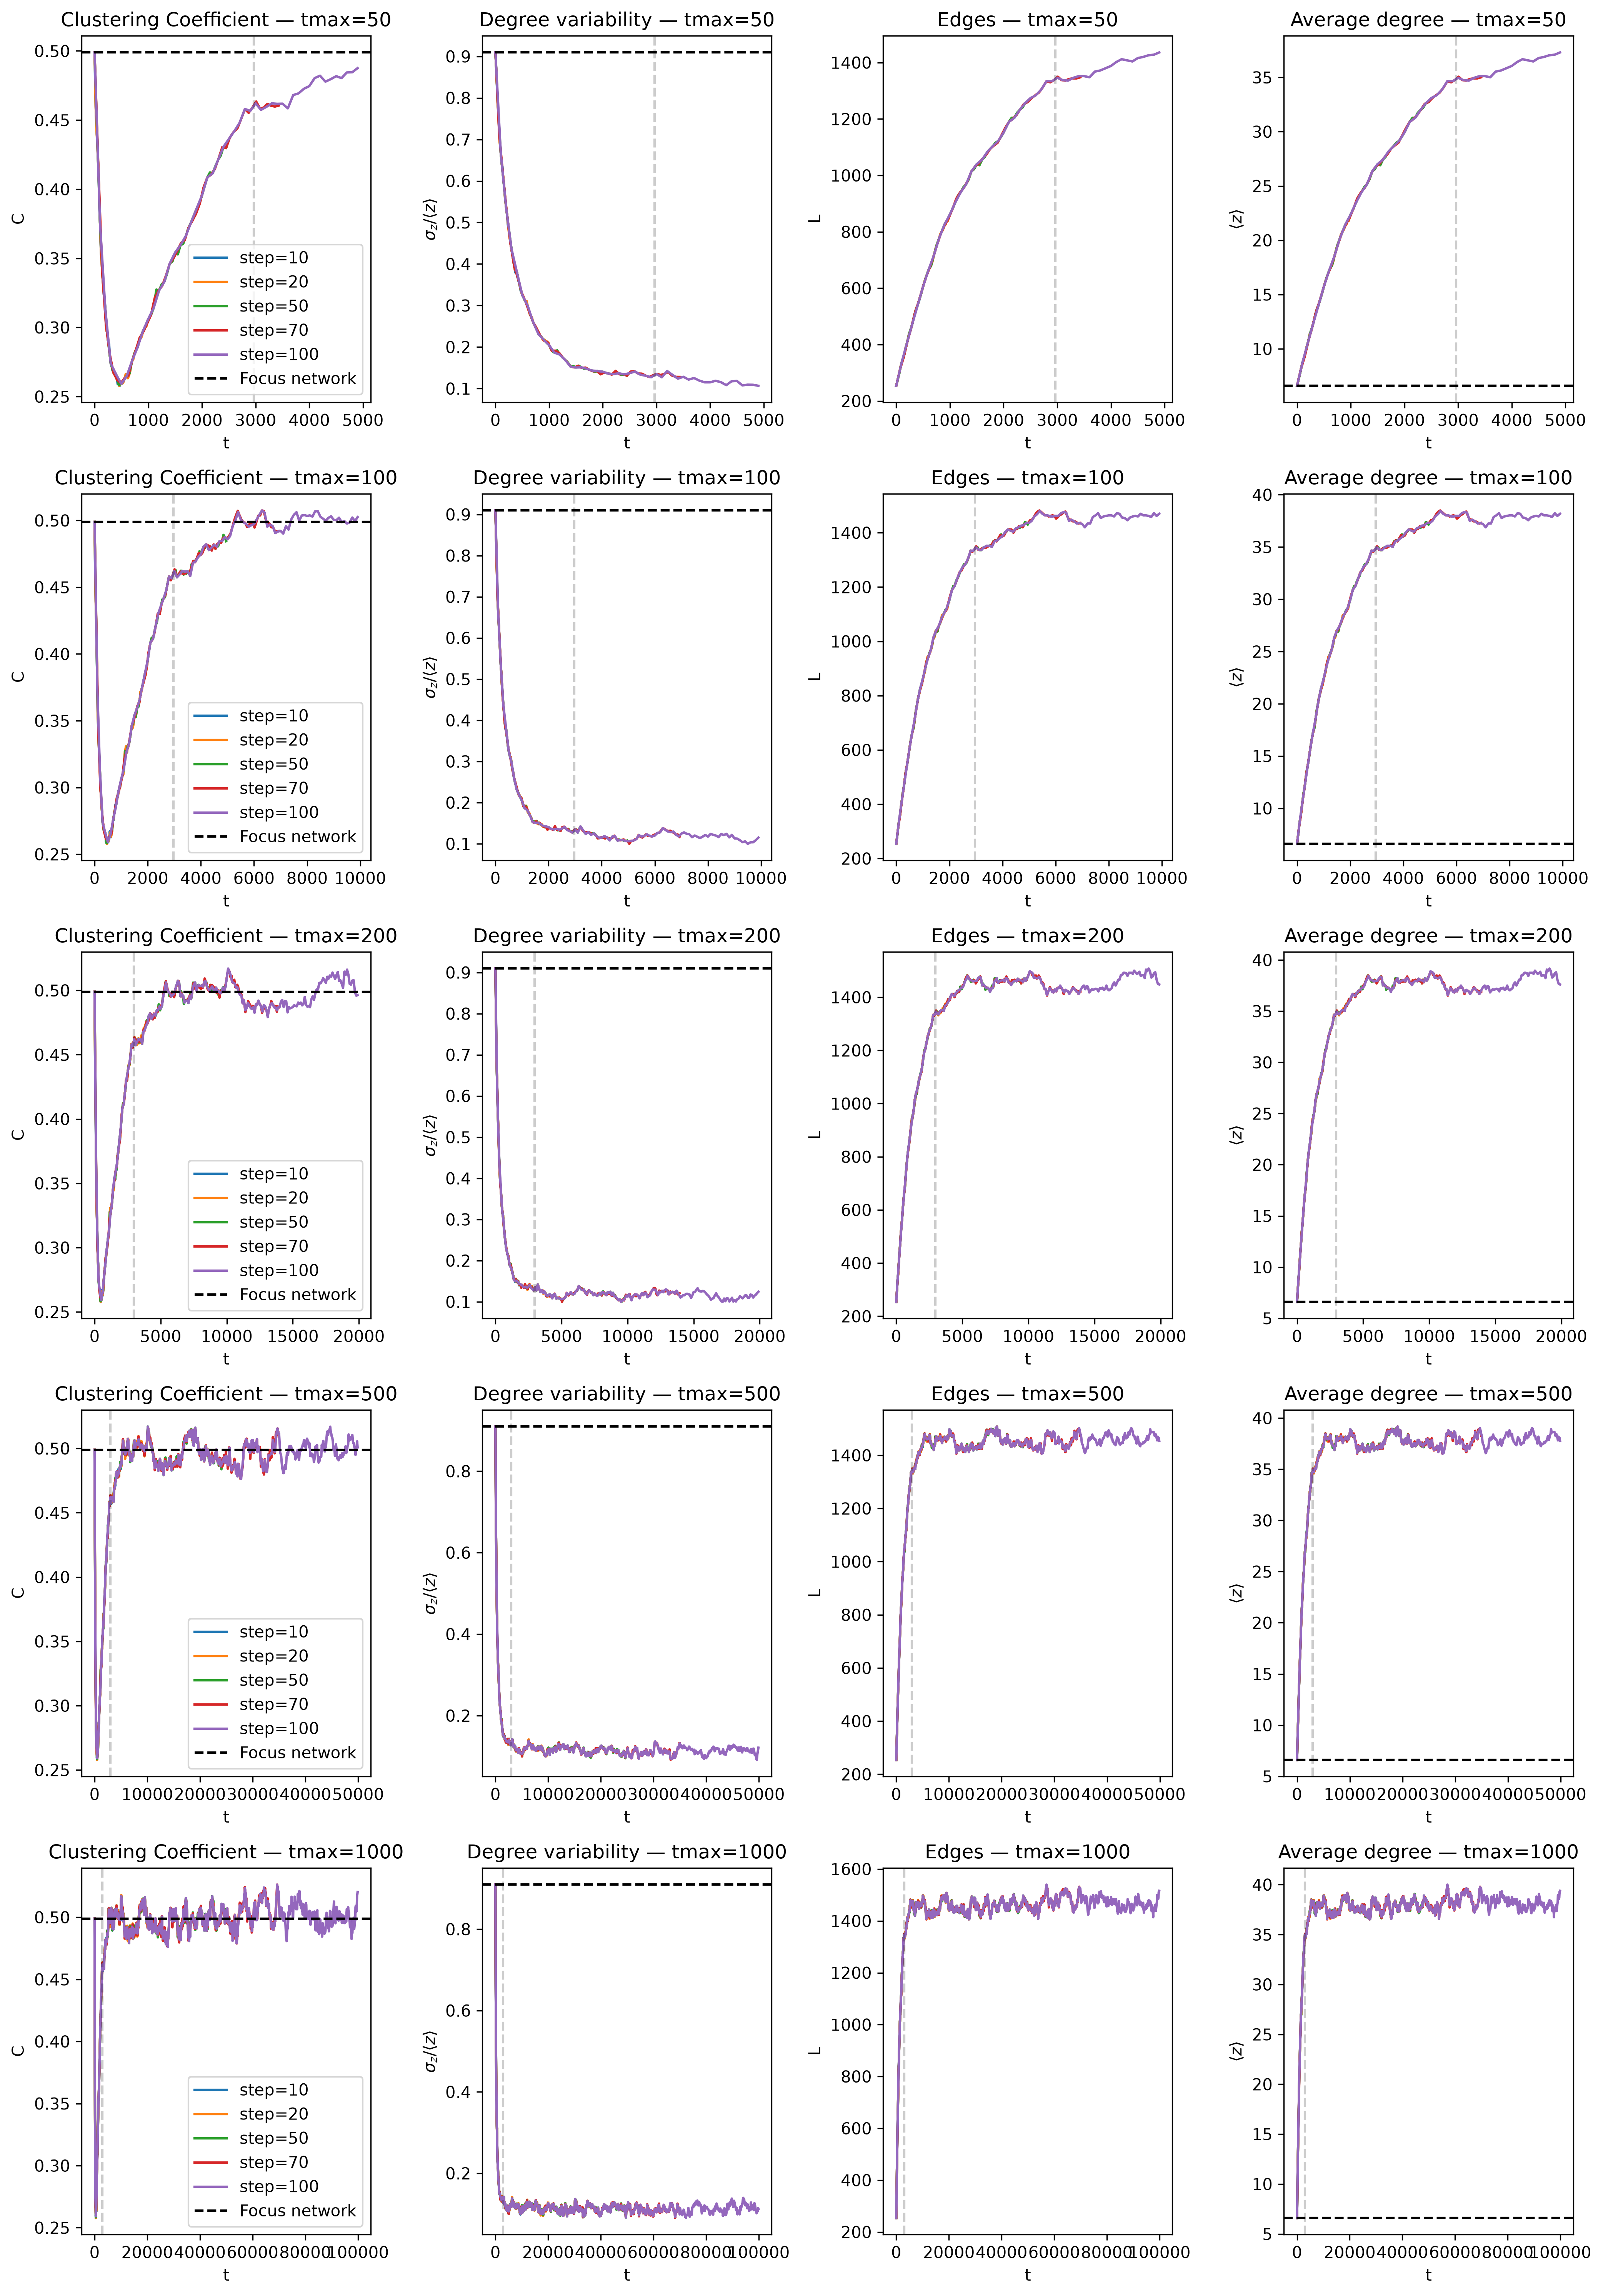

In [18]:
fig, axs = plt.subplots(5, 4, figsize=(14, 20), dpi=300)

for i, tmax in enumerate(tmx):
    for step in steps:
        output = pd.read_csv(OUTPUT_DIR / f"simulation_tmax{tmax}_step{step}.csv")
        ts, Ls, degrees, Cs, sigmas = output["time"], output["edges"], output["average_degree"], output["transitivity"], output["degree_variability"]

        axs[i, 0].plot(ts, Cs, label=f"step={step}")
        axs[i, 1].plot(ts, sigmas, label=f"step={step}")
        axs[i, 2].plot(ts, Ls, label=f"step={step}")
        axs[i, 3].plot(ts, degrees, label=f"step={step}")

    axs[i, 0].axvline(gs.number_of_nodes() ** 2 / 2, linestyle="--", color="black", alpha=0.2)
    axs[i, 1].axvline(gs.number_of_nodes() ** 2 / 2, linestyle="--", color="black", alpha=0.2)
    axs[i, 2].axvline(gs.number_of_nodes() ** 2 / 2, linestyle="--", color="black", alpha=0.2)
    axs[i, 3].axvline(gs.number_of_nodes() ** 2 / 2, linestyle="--", color="black", alpha=0.2)

    axs[i, 0].axhline(focus_C, linestyle="--", color="black", label="Focus network")
    axs[i, 1].axhline(focus_sigma, linestyle="--", color="black", label="Focus network")
    axs[i, 3].axhline(focus_degree, linestyle="--", color="black", label="Focus network")

    axs[i, 0].set(xlabel="t", ylabel="C", title=f"Clustering Coefficient — tmax={tmax}")
    axs[i, 1].set(xlabel="t", ylabel=r"$\sigma_z/\langle z \rangle$", title=f"Degree variability — tmax={tmax}")
    axs[i, 2].set(xlabel="t", ylabel=r"L", title=f"Edges — tmax={tmax}")
    axs[i, 3].set(xlabel="t", ylabel=r"$\langle z \rangle$", title=f"Average degree — tmax={tmax}")


    axs[i, 0].legend()

plt.tight_layout()
plt.show()

#### Some notes on results

- at equilibrium each possible edge is present with probability $p=0.5$. `gs` has $N=77$. Hence $\mathbb{E}[L] = 1/2 \cdot \binom{77}{2} = 1463$. Also $\mathbb{E}[\langle z \rangle] = (N-1)/2 = 38$. Both MCMC estimates approach these values.
- Recall that
$$p(t) = \frac{2L(t)}{N(N-1)}$$
- the initial graph is highly sparse with $C\approx 0.5$. As the randomised graphs lose structure and become denser, $p(t)$ increases as well. Hence $C(t) \approx p(t)$ increases as well.

## Exercise 1.3. Fixed degree sequence

Here we compare the focus network $g^*$ with random-graph models constructed from its degree sequence. We consider two approaches:

- i) The configuration-model multigraph obtained from the degree sequence of $g^*$ using `nx.configuration_model()`

- ii) An MCMC method starting at $g^*$ and using the edge-swap move (Example e from class): `nx.double_edge_swap()`

The configuration model first produces a multigraph that preserves the degree sequence exactly but may contain self-loops and parallel edges. For each realization, record these deviations and then create a simple graph by removing all self-loops and collapsing each set of parallel edges to one edge. Estimate:
- the expected total number of edges that would need to be removed to obtain a simple graph;
- the fraction of configuration-model realizations that are already simple;
- the expected clustering coefficient $\bar{C}_{cm}$ and its standard deviation $\sigma_{C_{cm}}$ after turning the network into a simple graph.


For the MCMC case, reproduce $C(t)$ to estimate the equilibration time, then use the post-burn-in samples to obtain $\bar{C}$ and $\sigma_C$ for the simple fixed-degree ensemble $\Omega_3$.


### Method (i)

In [19]:
def run_config_model_simulation(gs, num_samples=1000, seed=42):
    degree_sequence = [d for _, d in gs.degree()]

    rng = np.random.default_rng(seed)

    records = []

    for i in range(num_samples):
        G_cm = nx.configuration_model(degree_sequence, seed=int(rng.integers(0, 2**32 - 1)))

        L_raw = G_cm.number_of_edges()

        G_simple = nx.Graph(G_cm)
        G_simple.remove_edges_from(nx.selfloop_edges(G_simple))

        L_simple = G_simple.number_of_edges()

        edges_lost = L_raw - L_simple

        is_simple = (edges_lost == 0)

        C = nx.transitivity(G_simple)

        records.append({"sample": i, "edges_lost": edges_lost, "is_simple": is_simple, "transitivity": C})

    return pd.DataFrame(records)

In [20]:
print(f"Original graphs Number of Edges: {gs.number_of_edges()}\n")

df_cm = run_config_model_simulation(gs, num_samples=1000, seed=42)

print(f"Average edges lost: {df_cm["edges_lost"].mean()}")
print(f"Average number of simple graphs: {df_cm['is_simple'].mean()}") 
print(f"Average clustering coefficient: {df_cm["transitivity"].mean()}")
print(f"Standard deviation of clustering coefficient: {df_cm["transitivity"].std()}")


Original graphs Number of Edges: 254

Average edges lost: 30.452
Average number of simple graphs: 0.0
Average clustering coefficient: 0.16770068317928274
Standard deviation of clustering coefficient: 0.015741192435772874


### Method (ii)

In [21]:
def T3(g, rng):
    """Perform one degree-preserving double-edge swap in place."""
    nx.double_edge_swap(g, nswap=1, max_tries=100, seed=int(rng.integers(0, 2**32 - 1)))
    return g

def run_omega_3_simulation(gs, transf_func, seed, tmax=100, step=10):
    g = gs.copy()

    rng = np.random.default_rng(seed)

    outs = []
    N0 = g.number_of_nodes()
    L0 = g.number_of_edges()
    degree_sequence0 = dict(g.degree())

    for i in range(tmax):

        out = [i * step, nx.number_of_edges(g), measuresD(g), nx.transitivity(g)]

        outs.append(out)

        for _ in range(step):
            g = transf_func(g, rng)

        assert g.number_of_nodes() == N0
        assert g.number_of_edges() == L0
        assert dict(g.degree()) == degree_sequence0
        assert nx.number_of_selfloops(g) == 0

    output = pd.DataFrame(outs, columns=["time", "edges", "degree_variability", "transitivity"])

    return output

In [22]:
steps = [10, 20, 50, 70, 100]
tmx = [50, 100, 200, 500, 1000]

RUN = False
OUTPUT_DIR = Path("outputs/omega_3")
OUTPUT_DIR.mkdir(exist_ok=True)

gs_degrees = [gs.degree(n) for n in gs.nodes()]

focus_degree, focus_C, focus_sigma = np.average(gs_degrees), nx.transitivity(gs), measuresD(gs)

if RUN:
    for tmax in tmx:
        for step in steps:
            output = run_omega_3_simulation(gs, transf_func=T3, seed=RANDOM_SEED, tmax=tmax, step=step)
            output.to_csv(OUTPUT_DIR / f"simulation_tmax{tmax}_step{step}.csv", index=False)

tmax=50, step=10: C=nan, sigma=0.9095340315262034
tmax=50, step=20: C=nan, sigma=0.9095340315262034
tmax=50, step=50: C=nan, sigma=0.9095340315262034
tmax=50, step=70: C=nan, sigma=0.9095340315262034
tmax=50, step=100: C=nan, sigma=0.9095340315262034
tmax=100, step=10: C=nan, sigma=0.9095340315262034
tmax=100, step=20: C=nan, sigma=0.9095340315262034
tmax=100, step=50: C=nan, sigma=0.9095340315262034
tmax=100, step=70: C=nan, sigma=0.9095340315262034
tmax=100, step=100: C=nan, sigma=0.9095340315262034
tmax=200, step=10: C=nan, sigma=0.9095340315262034
tmax=200, step=20: C=nan, sigma=0.9095340315262034
tmax=200, step=50: C=nan, sigma=0.9095340315262034
tmax=200, step=70: C=nan, sigma=0.9095340315262034
tmax=200, step=100: C=nan, sigma=0.9095340315262034
tmax=500, step=10: C=0.20882409144604264, sigma=0.9095340315262034
tmax=500, step=20: C=0.20854613994857893, sigma=0.9095340315262034
tmax=500, step=50: C=0.20980560767146134, sigma=0.9095340315262034
tmax=500, step=70: C=0.2099532694044

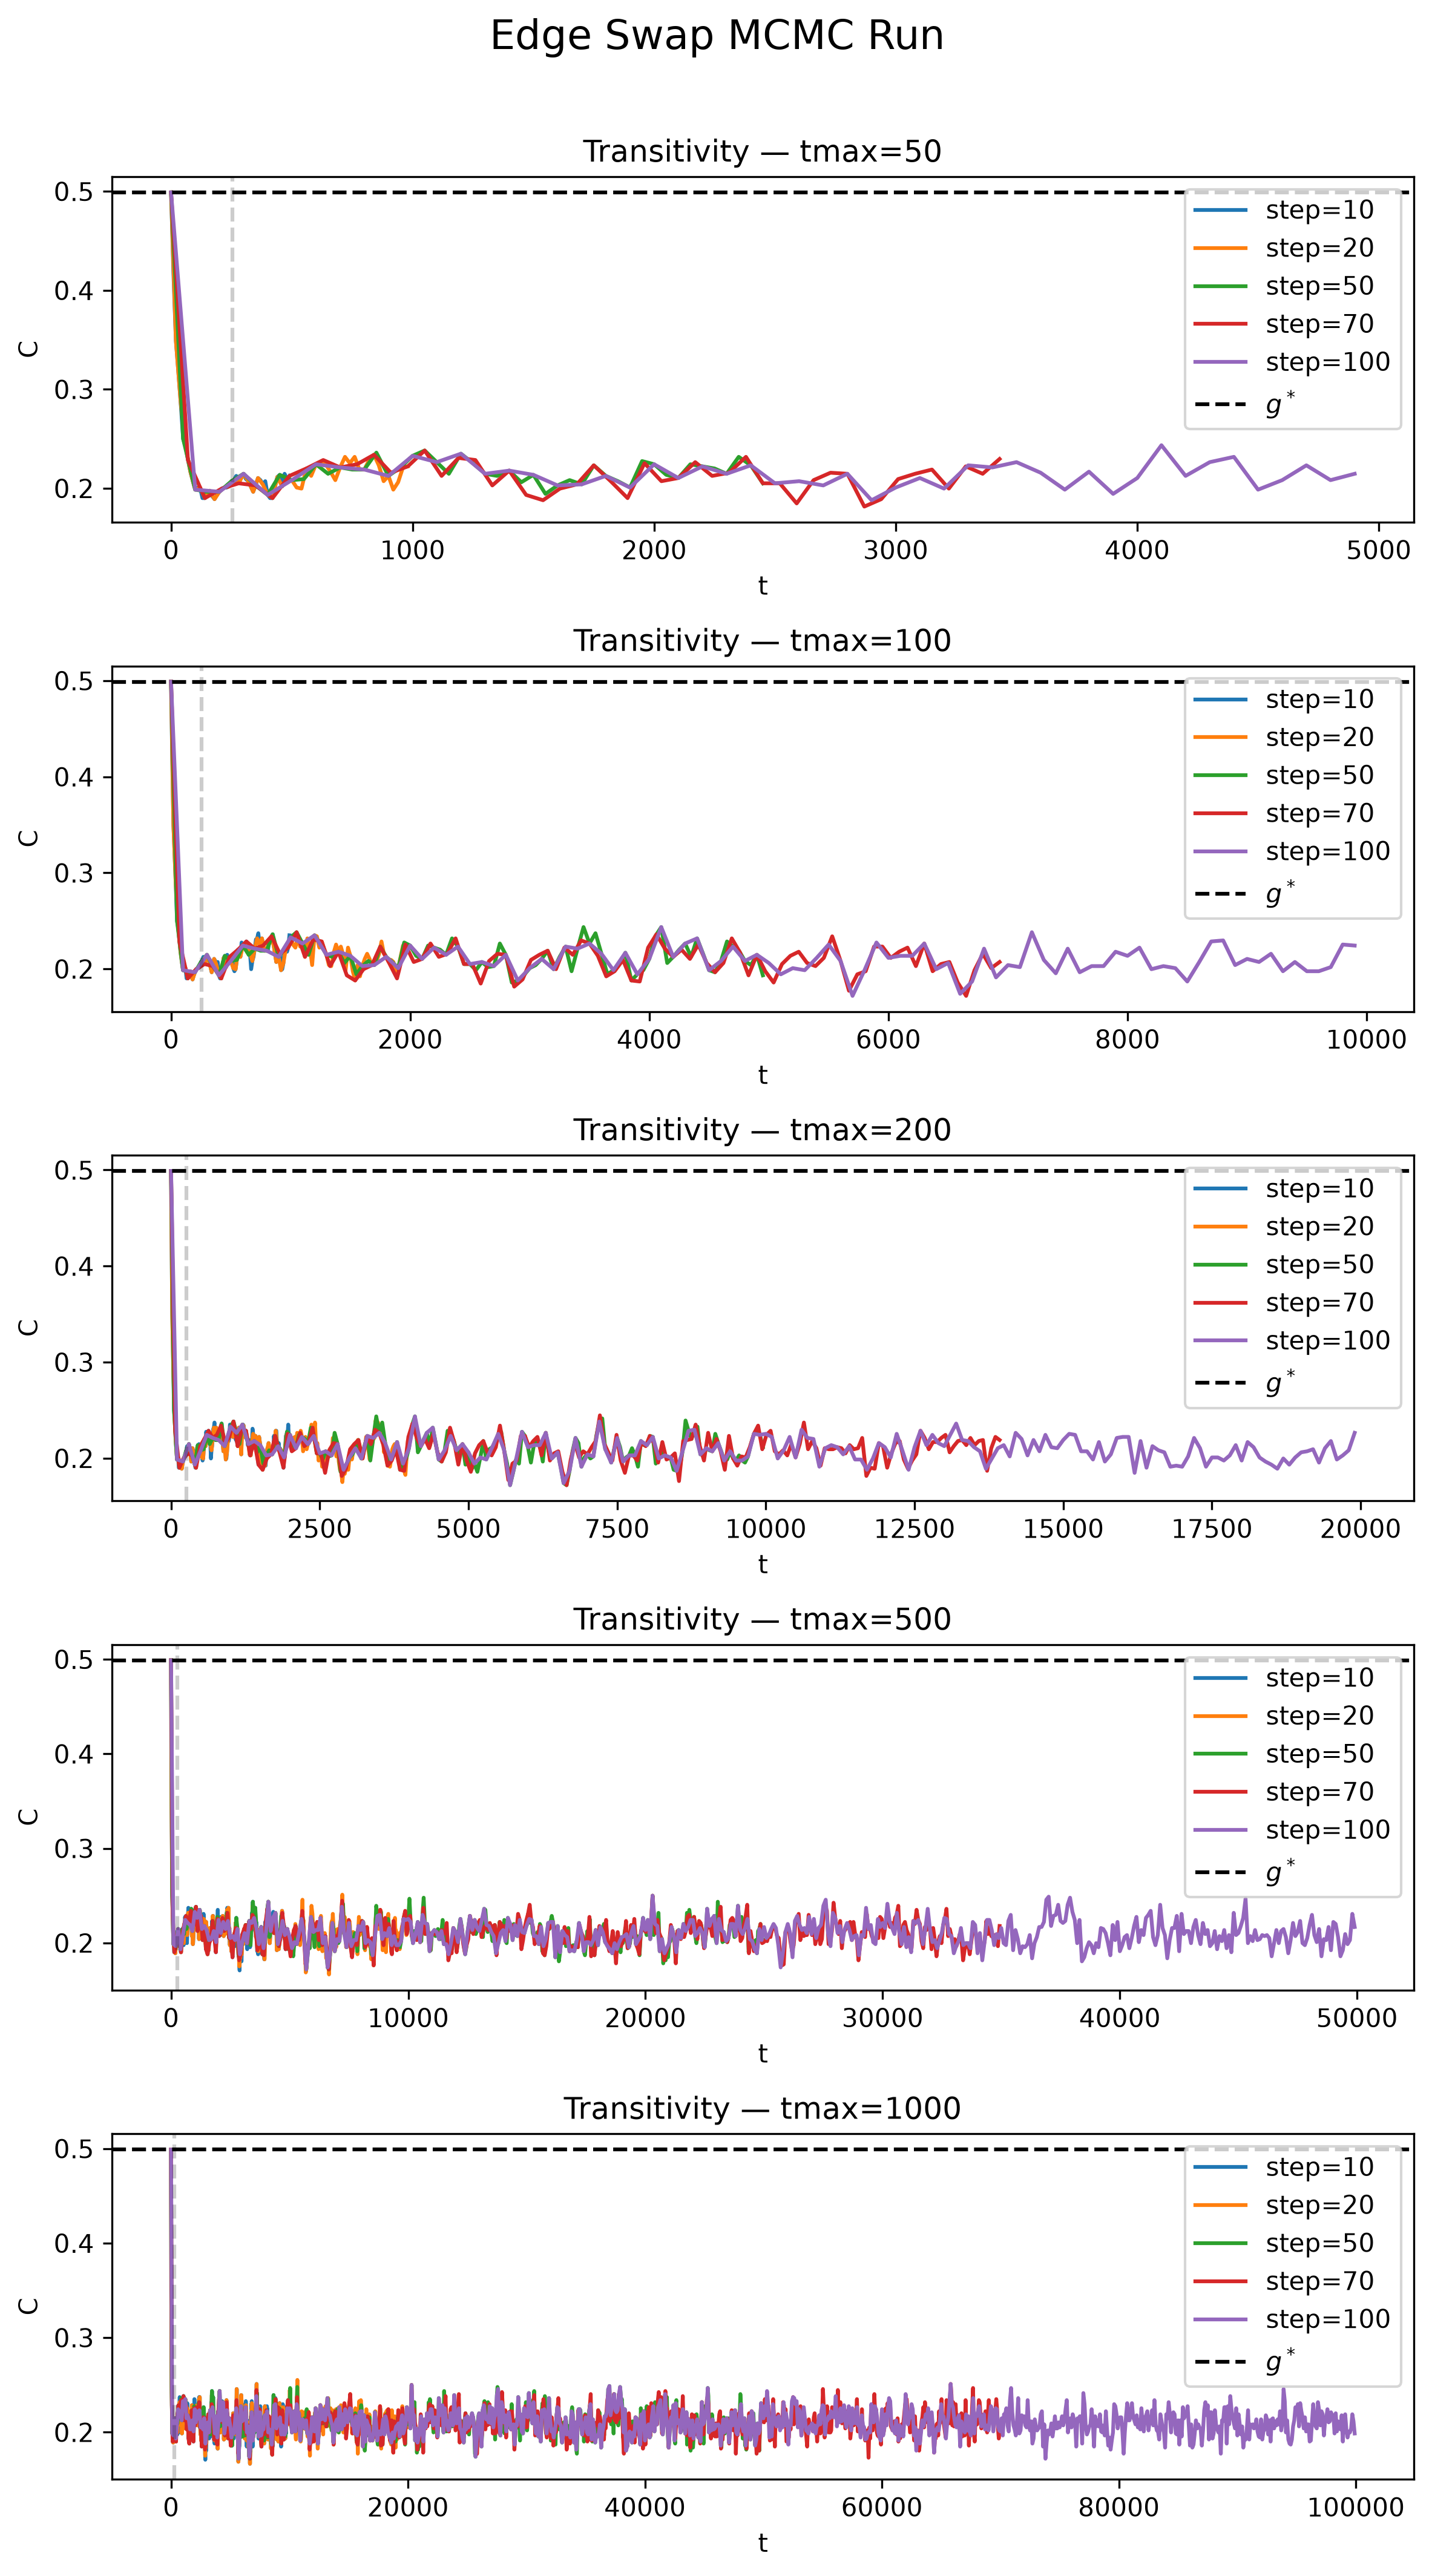

In [51]:
fig, axs = plt.subplots(5, 1, figsize=(8, 14), dpi=300)

for i, tmax in enumerate(tmx):
    for step in steps:
        output = pd.read_csv(OUTPUT_DIR / f"simulation_tmax{tmax}_step{step}.csv")
        ts, Cs = output["time"], output["transitivity"]

        average_C = np.mean(Cs[gs.number_of_edges():])
        average_sigma = np.mean(sigmas[gs.number_of_edges():])
        print(f"tmax={tmax}, step={step}: C={average_C}, sigma={average_sigma}")

        axs[i].plot(ts, Cs, label=f"step={step}")

    axs[i].axvline(gs.number_of_edges(), linestyle="--", color="black", alpha=0.2,)

    axs[i].axhline(focus_C, linestyle="--", color="black", label="$g^*$")

    axs[i].set(xlabel="t", ylabel="C", title=f"Transitivity — tmax={tmax}")

    axs[i].legend()

plt.suptitle("Edge Swap MCMC Run", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

- random simple graphs with the fixef degree sequence lower clustering
- observed high clustering therefore cannot be explained by the degree sequence alone

In [47]:
tmax=1000
step=100

sim_df_2 = pd.read_csv(f"outputs/omega_2/simulation_tmax{tmax}_step{step}.csv")[gs.number_of_edges():]
sim_df_3 =pd.read_csv(f"outputs/omega_3/simulation_tmax{tmax}_step{step}.csv")[gs.number_of_edges():]

C3_mean,C3_std = sim_df_3["transitivity"].mean(), sim_df_3["transitivity"].std()
C2_mean,C2_std = sim_df_2["transitivity"].mean(), sim_df_2["transitivity"].std()
C_star = nx.transitivity(gs)
Ccm_mean, Ccm_std = df_cm["transitivity"].mean(), df_cm["transitivity"].std()

def interval_3sigma(mean, std):
    return mean - 3*std, mean + 3*std

def intervals_overlap(mean1, std1, mean2, std2):
    a1, b1 = interval_3sigma(mean1, std1)
    a2, b2 = interval_3sigma(mean2, std2)
    return max(a1, a2) <= min(b1, b2)

def value_compatible_with_estimate(value, mean, std):
    lower, upper = interval_3sigma(mean, std)
    return lower <= value <= upper

print(f"C3 average: {C3_mean:.5f}, C3 std: {C3_std:.5f}\n")
print(f"C2 average: {C2_mean:.5f}, Compatible with C3:",intervals_overlap(C3_mean, C3_std, C2_mean, C2_std))
print(f"Ccm average: {Ccm_mean:.5f}, Compatible with C3:",intervals_overlap(C3_mean, C3_std, Ccm_mean, Ccm_std))
print(f"C_star: {C_star:.5f}, Compatible with C3:",intervals_overlap(C3_mean, C3_std, C_star, 0))
print("0 compatible with C3:",value_compatible_with_estimate(0, C3_mean, C3_std))
print("0.5 compatible with C3:",value_compatible_with_estimate(0.5, C3_mean, C3_std))

C3 average: 0.21039, C3 std: 0.01315

C2 average: 0.08589, Compatible with C3: False
Ccm average: 0.16770, Compatible with C3: True
C_star: 0.49893, Compatible with C3: False
0 compatible with C3: False
0.5 compatible with C3: False
